# 04. Machine learning: fire risk

**Owner:** Semrawit Haile  \
**Inputs:** see `config/paths.yml`  \
**Outputs:** figures to `reports/figures/`, data to `data/processed/`

## Purpose

The statistical analysis finds only weak evidence that ageing or depopulation are linked to larger burned areas.
In this notebook we explore whether demographic and settlement variables contain useful predictive information for identifying municipality-years with high burned-area impact.

The model estimates the risk of high burned-area impact using only the available demographic and settlement features. High-impact cases make up about 19% of the held-out data, while about 81% are lower-impact cases. becuase the two classes are uneven, we focus on average precision and the highest-ranked cases rather than accuracy alone @saitoPrecisionrecallPlotMore2015.

The model scores are then used to rank municipalities by relative prioritiy. Important fire drivers such as weather and vegetation are not included, so this ranking should be treated as partial prioritization tool rather than a complete wildfire forecast. Recent wildfire forecasting work similarly uses past data to predict later periods and produce local-area forecasts to support firefighting planning and resource allocation @huXGBoostMeetsINLA2026, p.4 ff .

## Setup

Every chapter starts with this identical cell. Do not add ad-hoc paths below it — put new paths in `config/paths.yml`.

In [5]:
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from wildfires.config import CONVENTIONS, MIN_FIRE_HA, PATHS, STUDY_YEARS
from wildfires.viz import apply_theme, save_figure

apply_theme()
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

from wildfires.io import load_panel
from wildfires.features import add_lags, fire_occurred
from wildfires.models.baseline import build_baseline, coefficient_table
from wildfires.models.tree_models import (
    build_random_forest, build_xgboost, evaluate_temporal, importance_table,
)


## Load panel and define the target

In [8]:
panel = load_panel() # fire x demography. 2019 - 2024

In [9]:
# column names
panel.columns

Index(['dtcc', 'year', 'n_fires', 'n_fires_gt24h', 'burned_ha_total', 'burned_ha_forest', 'burned_ha_shrub', 'burned_ha_agric',
       'burned_ha_total_ignited', 'burned_ha_forest_ignited', 'burned_ha_shrub_ignited', 'burned_ha_agric_ignited', 'n_fires_0_1ha',
       'n_fires_1_10ha', 'n_fires_10_20ha', 'n_fires_20_50ha', 'n_fires_50_100ha', 'n_fires_100_500ha', 'n_fires_500_1000ha',
       'n_fires_1000_plus_ha', 'cause_natural', 'cause_negligent', 'cause_intentional', 'cause_rekindle', 'cause_unknown',
       'cause_uninvestigated', 'effis_n_fires', 'effis_burnt_ha_total', 'effis_burnt_ha_median', 'effis_burnt_ha_max',
       'effis_duration_days_mean', 'effis_duration_days_max', 'lc_broadlea_mean', 'lc_conifer_mean', 'lc_mixed_mean', 'lc_scleroph_mean',
       'lc_transit_mean', 'lc_othernatlc_mean', 'lc_agriareas_mean', 'lc_artifsurf_mean', 'lc_otherlc_mean', 'percna2k_mean',
       'municipality_area_km2', 'burn_rate', 'burn_rate_ignited', 'territory', 'pop_total', 'pop_0_14', 'po

In [10]:
burn_pct = panel["burn_rate"]*100 # % of municipal area burned

print("Distribution of burn rate (% municipal area) 2019 - 2024;")
print(burn_pct.describe(percentiles=[0.05, 0.75, 0.8, 0.9, 0.95]).round(3))

Distribution of burn rate (% municipal area) 2019 - 2024;
count    1666.000
mean        0.970
std         3.636
min         0.000
5%          0.001
50%         0.058
75%         0.425
80%         0.630
90%         1.889
95%         3.860
max        50.636
Name: burn_rate, dtype: float64


In [11]:
pre_test_years = [2019, 2020, 2021, 2022]     # 2023-2024 held out

cutoff = (panel.loc[panel["year"].isin(pre_test_years), "burn_rate"] * 100).quantile(0.80)

panel["high_fire_impact"] = ((panel["burn_rate"] * 100) >= cutoff).astype(int)

print(f"Cutoff (from pre-test years only): {cutoff:.3f}%")
print(panel.groupby("year")["high_fire_impact"].agg(["sum", "mean"]).round(3))

Cutoff (from pre-test years only): 0.646%
      sum   mean
year            
2019   53  0.191
2020   55  0.198
2021   35  0.126
2022   80  0.288
2023   41  0.147
2024   65  0.234


The threshold for “high burned-area impact” is a burn rate above **0.646% of municipal area**. This cutoff was calculated using only the pre-test years.

The share of municipalities classified as high impact varies strongly from year to year, from **12.6% in 2021** to **28.8% in 2022**.

Such annual variation is unlikely to be explained by demographic and settlement characteristics alone. Important short-term drivers of burned area, such as drought, weather and vegetation conditions, are not included in the current model.

The model should therefore be interpreted as testing whether demographic and settlement variables contain useful predictive information, not as a complete explanation of burned-area variation.

## Feature matrix

The predictors describe demographic and settlement condition before a fire occurs. They are grouped on the main linkes in the conceptual model. The mode assumes that population decline can lead to land abandonment, which can increase vegetatin and fuel build-up. This may raise wildfire risk and, in turn, contribute to further population decline.

The following variables are excluded:

- fire outcomes (`n_fires*`, `burned_ha_*`, `cause_*`, `effis_*`, `burn_rate`) because these are the target or would introduce direct leakage;
- the `lc_*` land-cover fields — in `02_eda` are shares of vegetation *inside observed burn scars*, so they only exist once a fire has already happened and cannot predict whether one occurs.

In [41]:
# channels
CHANNELS = {
    "Ageing / potential land abandonment": [
        "share_65_plus", "share_75_plus", "aging_index",
        "old_age_dependency", "longevity_index", "renewal_index",
    ],
    "Depopulation / migration": [
        "growth_effective", "growth_migratory", "growth_natural",
    ],
    "Settlement intensity": [
        "pop_density", "pop_total", "birth_rate", "death_rate",
    ],
}
features = [c for cols in CHANNELS.values() for c in cols]

model_frame = panel.dropna(subset=features + ["high_fire_impact"]).copy()
model_frame["high_fire_impact"] = model_frame["high_fire_impact"].astype(int)

print(f"Feature matrix: {model_frame.shape[0]} municipality-years x {len(features)} features")
print(f"Positive rate (high_fire_impact): {model_frame['high_fire_impact'].mean():.1%}")
model_frame[features].describe().T.round(2)

Feature matrix: 1668 municipality-years x 13 features
Positive rate (high_fire_impact): 19.7%


,count,mean,std,min,25%,50%,75%,max
share_65_plus,1668.0,27.81,6.26,14.20,23.16,26.86,31.63,47.79
share_75_plus,1668.0,14.65,4.40,5.67,11.48,14.00,17.25,28.72
aging_index,1668.0,264.53,118.11,98.08,178.55,232.79,316.89,791.28
old_age_dependency,1668.0,46.80,14.61,19.80,36.19,43.75,54.25,103.51
longevity_index,1668.0,51.90,5.07,39.20,48.70,51.70,54.92,72.70
renewal_index,1668.0,70.18,12.17,35.50,62.00,70.30,78.60,120.80
growth_effective,1668.0,0.10,0.99,-3.87,-0.56,-0.05,0.70,3.69
growth_migratory,1668.0,0.93,0.80,-0.82,0.35,0.76,1.40,4.17
growth_natural,1668.0,-0.83,0.60,-3.68,-1.17,-0.77,-0.37,0.42
pop_density,1668.0,311.08,860.71,3.60,22.88,64.75,173.02,7799.80


## Train/test split by time

In [42]:
# split
train_df = model_frame[model_frame.year.isin(pre_test_years)]
test_df  = model_frame[model_frame.year.isin([2023, 2024])]

X_train, y_train = train_df[features], train_df["high_fire_impact"]
X_test,  y_test  = test_df[features],  test_df["high_fire_impact"]

split_summary = pd.DataFrame({
    "period": ["train", "test"],
    "years": ["2019-2022", "2023-2024"],
    "rows": [len(train_df), len(test_df)],
    "positive_rate": [round(y_train.mean(), 3), round(y_test.mean(), 3)],
})
split_summary

,period,years,rows,positive_rate
0,train,2019-2022,1112,0.201
1,test,2023-2024,556,0.191


The class balance is similar in training and testing (about 20% high-impact cases in each period).

## Baseline: logistic regression

We use average precision as the main metric because the positive class is minority and the task is ranking high-impact cases.

In [30]:
# logistic regression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

BASE_RATE = y_test.mean()
TOP_K = 20  # municipalities a prevention team could realistically prioritise


def precision_at_k(y_true, scores, k=TOP_K):
    order = np.argsort(np.asarray(scores))[::-1][:k]
    return np.asarray(y_true)[order].mean()


def evaluate(name, model):
    p = model.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "avg_precision": average_precision_score(y_test, p),
        "roc_auc": roc_auc_score(y_test, p),
        f"precision@{TOP_K}": precision_at_k(y_test, p),
    }


logit = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced"),
).fit(X_train, y_train)

logit_scores = evaluate("Logistic regression", logit)
print(f"Test base rate (chance): {BASE_RATE:.1%}")
print(logit_scores)

coefs = pd.Series(
    logit.named_steps["logisticregression"].coef_[0], index=features
).sort_values(key=abs, ascending=False)
coefs.rename("std_coefficient").to_frame().round(3)

Test base rate (chance): 19.1%
{'model': 'Logistic regression', 'avg_precision': 0.3401527125707127, 'roc_auc': 0.7103983228511531, 'precision@20': np.float64(0.4)}


,std_coefficient
old_age_dependency,-1.182
aging_index,0.860
share_65_plus,0.817
pop_total,-0.432
birth_rate,-0.430
longevity_index,-0.385
death_rate,-0.359
growth_migratory,-0.278
renewal_index,0.204
growth_natural,0.182


The logistic regression provides a simple baseline for testing whether the
demographic and settlement variables contain predictive information.

On the held-out 2023–2024 data, the model achieves an **average precision of
0.34**, compared with a **19.1% base rate**, and a **ROC-AUC of 0.71**. This
suggests that the variables contain some useful information for distinguishing
higher- from lower-impact municipality-years.

Several ageing indicators receive relatively large coefficients, but their
signs differ. Because these variables measure closely related demographic
characteristics, the individual coefficients should not be interpreted as
separate causal effects.

Instead, we focus on how well the model works on new years and which groups of variables are most useful for prediction.

## Random Forest

In [31]:
# random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400, class_weight="balanced", random_state=0, n_jobs=-1,
).fit(X_train, y_train)

rf_scores = evaluate("Random Forest", rf)
print(rf_scores)

{'model': 'Random Forest', 'avg_precision': 0.3975982790198263, 'roc_auc': 0.7568343815513627, 'precision@20': np.float64(0.4)}


## XGBoost

In [32]:
# xgboost
from xgboost import XGBClassifier

pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
xgb = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", scale_pos_weight=pos_weight, random_state=0,
).fit(X_train, y_train)

xgb_scores = evaluate("XGBoost", xgb)
print(xgb_scores)

{'model': 'XGBoost', 'avg_precision': 0.40941665629978785, 'roc_auc': 0.7496436058700209, 'precision@20': np.float64(0.4)}


## Model comparison

,avg_precision,roc_auc,precision@20
model,,,
Logistic regression,0.340,0.710,0.4
Random Forest,0.398,0.757,0.4
XGBoost,0.409,0.750,0.4


Best model on held-out average precision: XGBoost


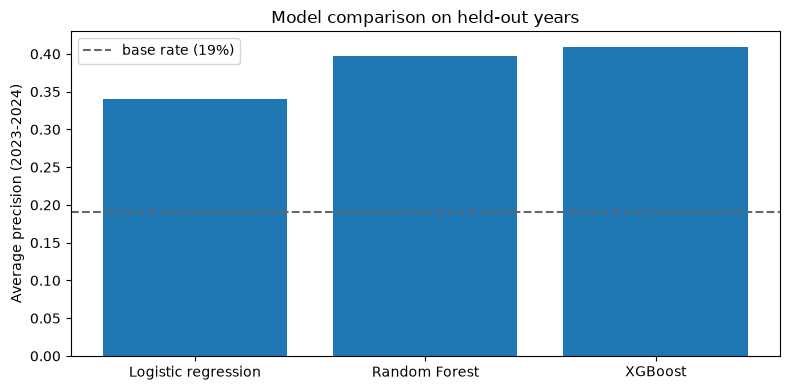

In [33]:
# compare models
models = {"Logistic regression": logit, "Random Forest": rf, "XGBoost": xgb}
comparison = pd.DataFrame([logit_scores, rf_scores, xgb_scores]).set_index("model")
display(comparison.round(3))

best_name = comparison["avg_precision"].idxmax()
best_model = models[best_name]
print(f"Best model on held-out average precision: {best_name}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comparison.index, comparison["avg_precision"])
ax.axhline(BASE_RATE, color="0.4", linestyle="--", label=f"base rate ({BASE_RATE:.0%})")
ax.set_ylabel("Average precision (2023-2024)")
ax.set_title("Model comparison on held-out years")
ax.legend()
fig.tight_layout()
save_figure(fig, "model_comparison_ap")
plt.show()

Random Forest and XGBoost both improve on the logistic regression.

Random Forest reaches an **average precision of 0.398** and **ROC-AUC of 0.757**.
XGBoost has the highest average precision at **0.409**, while Random Forest has
a slightly higher ROC-AUC.

Both models have **40% precision among the top 20 highest-risk predictions**.

Overall, XGBoost gives the best ranking performance, but the difference between
the two tree-based models is small.

In [34]:
# Check whether performance is consistent across the two held-out years.
yearly_rows = []
for year in [2023, 2024]:
    mask = test_df["year"].eq(year)
    X_year = test_df.loc[mask, features]
    y_year = test_df.loc[mask, "high_fire_impact"]
    p_year = best_model.predict_proba(X_year)[:, 1]

    yearly_rows.append({
        "year": year,
        "n": int(mask.sum()),
        "positive_rate": y_year.mean(),
        "average_precision": average_precision_score(y_year, p_year),
        "roc_auc": roc_auc_score(y_year, p_year),
    })

yearly_performance = pd.DataFrame(yearly_rows).set_index("year")
display(yearly_performance.round(3))



,n,positive_rate,average_precision,roc_auc
year,,,,
2023,278,0.147,0.324,0.724
2024,278,0.234,0.500,0.769


The model performs better in 2024 than in 2023, but it shows useful predictive
power in both years.

In 2023, average precision is **0.324** compared with a base rate of **14.7%**.
In 2024, average precision increases to **0.500** compared with a base rate of
**23.4%**.

ROC-AUC is also above 0.70 in both years. This suggests that the model's
predictive signal is not driven by only one test year, although performance
still varies from year to year.

## Importance and Ranking

To measure each channel's importance, we randomly shuffle its values and check
how much the model's performance decreases. A larger decrease means the model
relies more strongly on that channel for prediction.

,importance,std,relative_pct
channel,,,
Settlement intensity,0.136,0.018,43.856
Ageing / potential land abandonment,0.134,0.021,43.151
Depopulation / migration,0.040,0.019,12.993


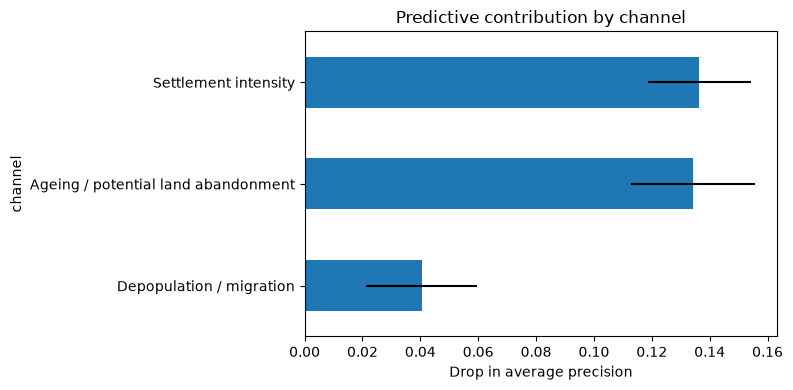

In [35]:
# Rank contextual channels by how much model performance drops
# when all variables in that channel are shuffled together.

rng = np.random.default_rng(0)
baseline_ap = average_precision_score(
    y_test, best_model.predict_proba(X_test)[:, 1]
)

results = []

for channel, cols in CHANNELS.items():
    drops = []

    for _ in range(30):
        X_shuffled = X_test.copy()
        X_shuffled[cols] = rng.permutation(X_shuffled[cols].to_numpy())

        ap = average_precision_score(
            y_test,
            best_model.predict_proba(X_shuffled)[:, 1]
        )

        drops.append(baseline_ap - ap)

    results.append({
        "channel": channel,
        "importance": np.mean(drops),
        "std": np.std(drops)
    })

channel_rank = (
    pd.DataFrame(results)
    .set_index("channel")
    .sort_values("importance", ascending=False)
)

# relative contribution
channel_rank["relative_pct"] = (
    channel_rank["importance"]
    / channel_rank["importance"].sum()
    * 100
)

display(channel_rank.round(3))

# Plot
channel_rank.sort_values("importance")["importance"].plot.barh(
    xerr=channel_rank.sort_values("importance")["std"],
    figsize=(8, 4)
)

plt.xlabel("Drop in average precision")
plt.title("Predictive contribution by channel")
plt.tight_layout()
plt.show()


Settlement intensity and ageing / potential land abandonment contribute almost
equally to prediction, while depopulation / migration contributes much less.

Shuffling the first two channels reduces average precision by about **0.13**,
compared with only **0.04** for depopulation / migration.

This means the model relies much more on settlement and ageing-related variables
than on migration variables. However, these are predictive contributions only
and should not be interpreted as causal effects.

## Backtest on held-out years

In [44]:
# Predictions for held-out municipality-years
risk = test_df[["dtcc", "year"]].copy()
risk["predicted_risk"] = best_model.predict_proba(X_test)[:, 1]
risk["observed_high_impact"] = y_test.to_numpy()

ap = average_precision_score(
    risk["observed_high_impact"],
    risk["predicted_risk"],
)

base_rate = risk["observed_high_impact"].mean()

precision_k = precision_at_k(
    risk["observed_high_impact"],
    risk["predicted_risk"],
)

print(f"Average precision: {ap:.3f}")
print(f"Base rate: {base_rate:.1%}")
print(f"Precision@{TOP_K}: {precision_k:.0%}")

Average precision: 0.409
Base rate: 19.1%
Precision@20: 40%


The model ranks high--impact cases better than a random ranking. At 40% Precision@20 8 out of 20 predictions were high-impact.


In [45]:
# Average risk across held-out years, then rank municipalities
priority = (
    risk.groupby("dtcc", as_index=False)
        .agg(
            predicted_risk=("predicted_risk", "mean"),
            high_impact_any_year=("observed_high_impact", "max"),
        )
        .sort_values("predicted_risk", ascending=False)
)

priority["priority_rank"] = range(1, len(priority) + 1)

top = priority.head(TOP_K).copy()

municipality_base_rate = priority["high_impact_any_year"].mean()
top_hit_rate = top["high_impact_any_year"].mean()

display(
    top[
        ["priority_rank", "dtcc", "predicted_risk", "high_impact_any_year"]
    ]
)

print(f"Municipality base rate: {municipality_base_rate:.0%}")
print(f"Top-{TOP_K} hit rate: {top_hit_rate:.0%}")

# each municipality appears only once. The predicted risk is averaged across the held-out years.
# a municipality counts as high impact if it had high impact in at least one held-out year.

,priority_rank,dtcc,predicted_risk,high_impact_any_year
162,1,1116,0.896149,0
178,2,1301,0.892754,1
230,3,1601,0.879160,1
251,4,1712,0.864782,0
39,5,0307,0.862888,1
244,6,1705,0.862740,0
61,7,0503,0.811726,0
36,8,0304,0.807200,1
184,9,1307,0.804822,1
266,10,1813,0.790457,1


Municipality base rate: 29%
Top-20 hit rate: 70%


High impact occured in 29% of municipalities overall, but in 70% of the top 20 municipalities selected  by the model. This suggests that the ranking concentrated higher-risk municipalities.

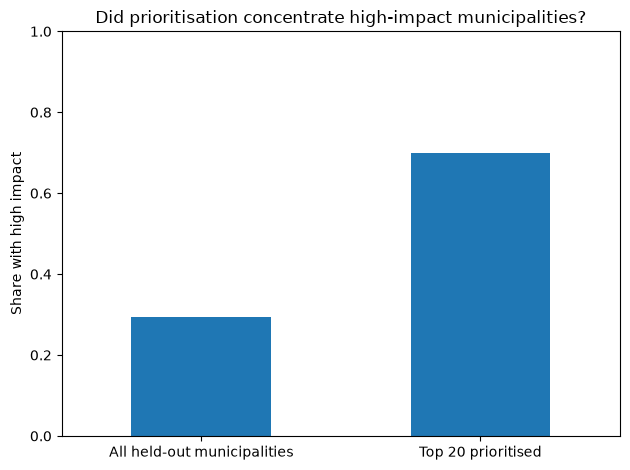

In [47]:
comparison = pd.Series({
    "All held-out municipalities": municipality_base_rate,
    f"Top {TOP_K} prioritised": top_hit_rate,
})

ax = comparison.plot.bar(
    ylim=(0, 1),
    rot=0,
    ylabel="Share with high impact",
    title="Did prioritisation concentrate high-impact municipalities?",
)

plt.tight_layout()
plt.show()

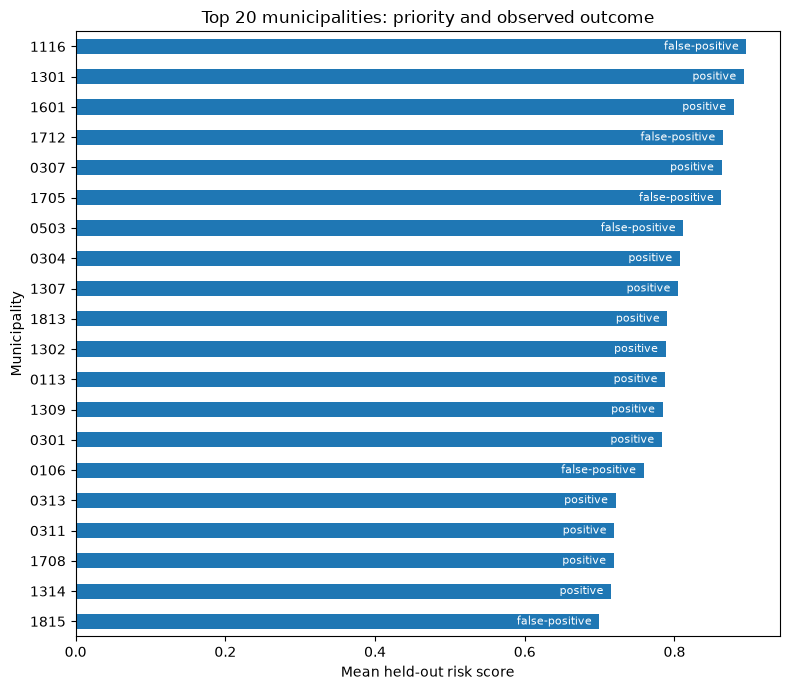

In [55]:
plot_data = top.sort_values("predicted_risk")

ax = plot_data.plot.barh(
    x="dtcc",
    y="predicted_risk",
    figsize=(8, 7),
    legend=False,
)

for i, observed in enumerate(plot_data["high_impact_any_year"]):
    ax.text(
        plot_data["predicted_risk"].iloc[i] - 0.01,
        i,
        "positive" if observed else "false-positive",
        va="center",
        ha="right",
        fontsize=8,
        color="white",
    )

ax.set_xlabel("Mean held-out risk score")
ax.set_ylabel("Municipality")
ax.set_title(f"Top {TOP_K} municipalities: priority and observed outcome")

plt.tight_layout()
plt.show()

the model ranks municipalities by their mean risk score across the held-out years. among the top 20 municipalities, 70% experienced high impact in at least one held-out year, while 30% were false positives.

## Agent-based Simulation

The interactive agent, a simple conceptual model, based NetLogo model below illustrates the assumed link between demographic change, land abandonment, fuel accumulation, wildfire,and further population decline [@courseMiroboard;@wilensky1997wolfsheep; @wilensky1999netlogo].

:::{iframe} /wildfire.html
:width: 100%
:height: 750px
:::

## Takeaways

- the model identifies meaningful risk patterns: average precision is above the held-out base rate.
- prioritization concentrates high-impact municipalities near the top of ranking (top 20), although some false positives remain.
- the risk score is best interpreted as a relative priority score, not as a calibrated probability of future fire impact.

## Outlook.
- given that the dataset is small (2019-2024), the model needs to be tested over a longer time period.
- more variables for weather and vegetation condition need to be added in order to approximate to the true story.
